# Computational Trade-Offs

Measures two overhead components:
1. **ML inference latency:** `predict_proba()` on 10,000 rows repeated 7 times, using the saved Split 4 model artifacts
2. **Live eBPF collector:** CPU% and RSS for the `netmon` process across 3 runs on a dedicated Ubuntu 20.04 server

**RQ4:** What are the computational trade-offs of eBPF-enhanced detection?

In [ ]:
import os, sys, json, subprocess
import matplotlib.pyplot as plt
from pathlib import Path

HERE = Path.cwd().resolve()
REPO_ROOT = None
for _p in [HERE] + list(HERE.parents):
    if (_p / 'ml').exists() and (_p / 'data').exists():
        REPO_ROOT = _p
        break
assert REPO_ROOT
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

from ml.notebooks.experiment_config import GENERALIZATION_SPLITS_BASELINE, GENERALIZATION_SPLITS_EBPF, MODELS_DIR, RANDOM_SEED

BASELINE_SPLITS = Path(GENERALIZATION_SPLITS_BASELINE)
EBPF_SPLITS     = Path(GENERALIZATION_SPLITS_EBPF)
BASELINE_MODEL  = Path(MODELS_DIR) / f'baseline_headline_model_seed{RANDOM_SEED}.joblib'
EBPF_MODEL      = Path(MODELS_DIR) / f'ebpf_headline_model_seed{RANDOM_SEED}.joblib'

OUT_JSON = Path('data/reports/overheads/overheads.json')
OUT_DIR  = Path('data/reports/overheads/artifacts')

OUT_JSON.parent.mkdir(parents=True, exist_ok=True)

REPORTS_DIR = REPO_ROOT / 'data' / 'reports'
OVERHEADS_DIR = REPORTS_DIR / 'overheads'

BASELINE_COLOR = "#4C78A8"
EBPF_COLOR = "#F58518"
NEUTRAL_COLOR = "#9AA1A9"

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#6B7280',
    'axes.labelcolor': '#111827',
    'axes.titleweight': 'bold',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.color': '#374151',
    'ytick.color': '#374151',
    'grid.color': '#D7DBDF',
    'grid.linestyle': '--',
    'grid.alpha': 0.35,
    'legend.frameon': False,
    'savefig.facecolor': 'white',
    'savefig.bbox': 'tight',
})

def savefig(fig, path, dpi=180):
    """Save matplotlib figure to path."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=dpi, bbox_inches='tight')


In [2]:
cmd = [
    'python3', 'ml/benchmarks/overheads.py',
    '--baseline_splits_dir', str(BASELINE_SPLITS),
    '--ebpf_splits_dir', str(EBPF_SPLITS),
    '--baseline_model_pack', str(BASELINE_MODEL),
    '--ebpf_model_pack', str(EBPF_MODEL),
    '--test_file', 'test_realistic',
    '--skip_training',
    '--infer_sample_n', '10000',
    '--infer_repeats', '7',
    '--out_json', str(OUT_JSON),
    '--out_dir', str(OUT_DIR),
]

print(' '.join(cmd))
subprocess.run(cmd, check=True)

data = json.loads(OUT_JSON.read_text())
print(json.dumps(data.get('benchmark_protocol', {}), indent=2))
data


python3 ml/benchmarks/overheads.py --baseline_splits_dir /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/datasets/split4_dual_eval_baseline_seed104 --ebpf_splits_dir /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/datasets/split4_dual_eval_ebpf_seed104 --baseline_model_pack /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/models/baseline_headline_model_seed104.joblib --ebpf_model_pack /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/models/ebpf_headline_model_seed104.joblib --test_file test_realistic --skip_training --infer_sample_n 10000 --infer_repeats 7 --out_json data/reports/overheads/overheads.json --out_dir data/reports/overheads/artifacts
[OK] Wrote data/reports/overheads/overheads.json
{
  "train_load_measurement": "wall_clock_seconds_to_read_train_parquet",
  "test_load_measurement": "wall_clock_seconds_to_read_requested_test_parquet",
  "inference_measurement": "saved-artifact scoring latency on a fixed first-N-row sample after one w

{'system': {'timestamp_utc': '2026-04-01T22:34:06Z',
  'python': '3.10.12',
  'platform': 'Linux-6.6.87.2-microsoft-standard-WSL2+-x86_64-with-glibc2.35',
  'machine': 'x86_64',
  'cpu_count': 16},
 'inputs': {'baseline_splits_dir': '/mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/datasets/split4_dual_eval_baseline_seed104',
  'ebpf_splits_dir': '/mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/datasets/split4_dual_eval_ebpf_seed104',
  'baseline_model_pack': '/mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/models/baseline_headline_model_seed104.joblib',
  'ebpf_model_pack': '/mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/models/ebpf_headline_model_seed104.joblib',
  'test_file': 'test_realistic',
  'label_col': 'is_attack',
  'skip_training': True},
 'load_times_seconds': {'baseline_train': 3.7752665209700353,
  'baseline_test': 1.0678971899906173,
  'ebpf_train': 2.664261312049348,
  'ebpf_test': 1.0114829129888676},
 'dataset_shapes': {'ba

## ML Inference Overhead

Artifact load time, mean inference latency, and model size for both models on the Split 4 realistic test set.

[+] Saved overhead summary table: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/overheads_summary_seed104.csv


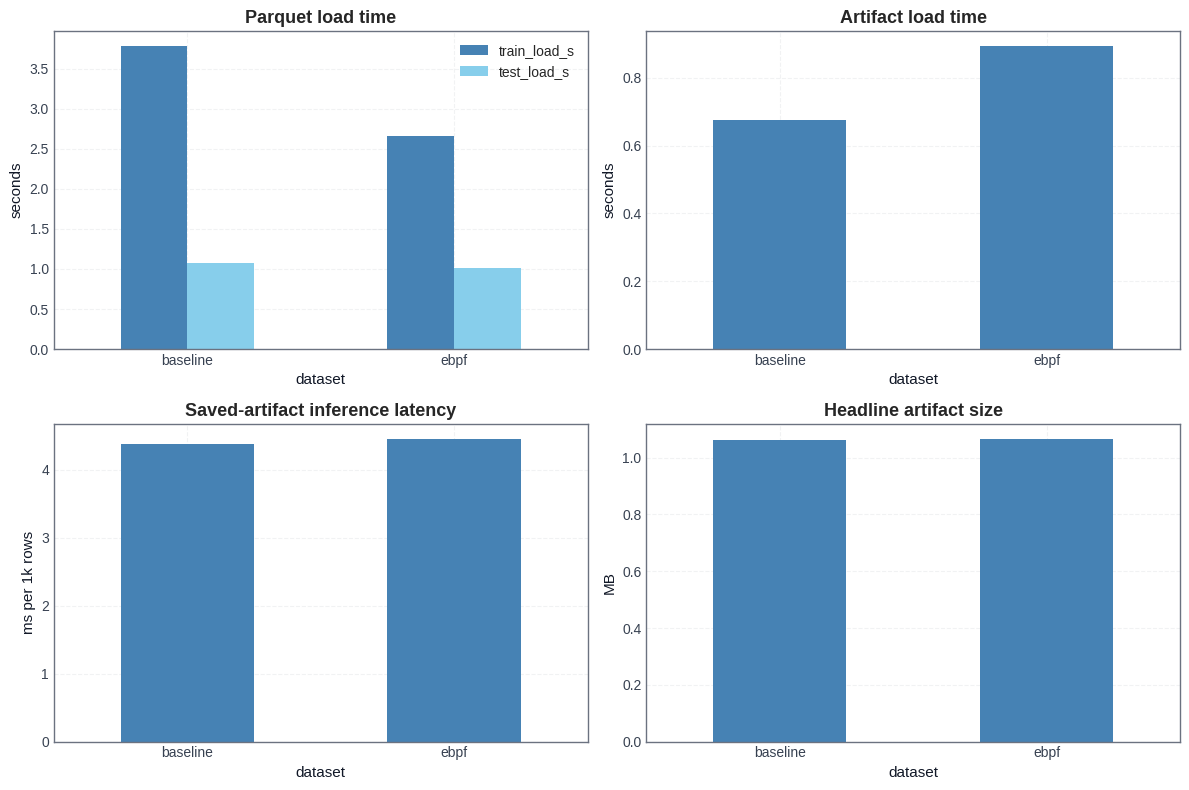

[+] Saved overhead figure: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/overheads/overheads_summary_seed104.png


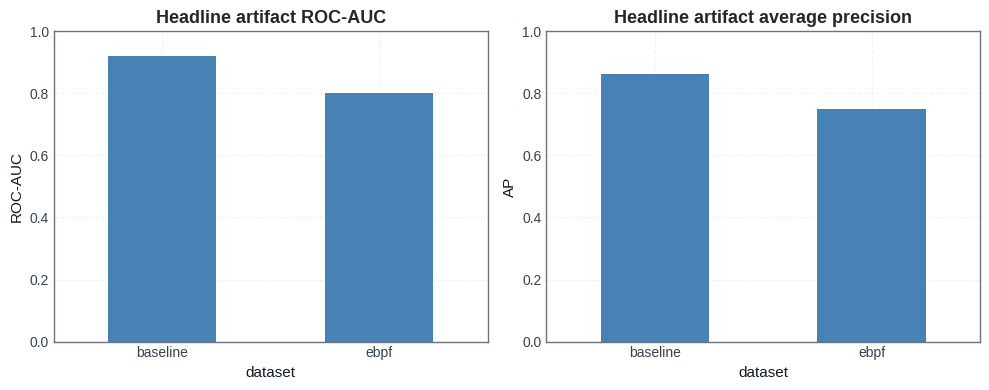

[+] Saved overhead quality figure: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/overheads/overheads_quality_seed104.png


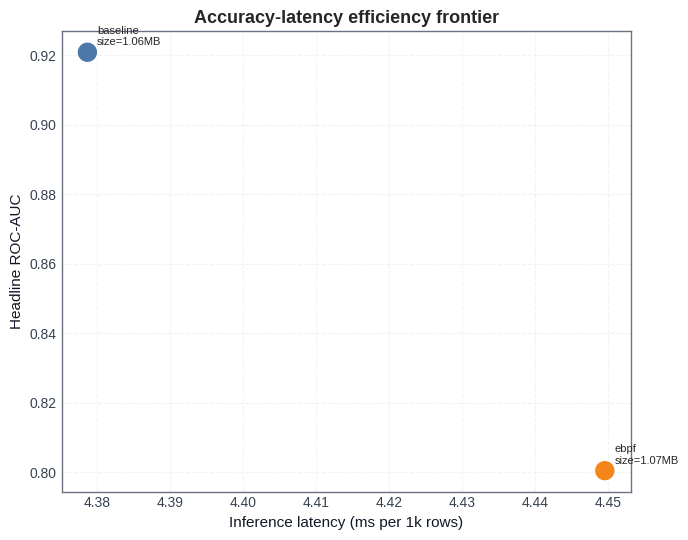

[+] Saved efficiency frontier: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/overheads/overheads_efficiency_frontier_seed104.png


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

models_df = pd.DataFrame(data['models'])
models_df

summary_df = models_df.copy()
summary_df['model_size_mb'] = summary_df['model_size_bytes'] / (1024 ** 2)
summary_cols = [
    'dataset', 'model', 'artifact_load_seconds', 'latency_mean_seconds',
    'latency_std_seconds', 'infer_ms_per_1k', 'infer_rows_benchmarked',
    'latency_repeats', 'model_size_mb', 'test_auc', 'test_ap',
]
summary_cols = [c for c in summary_cols if c in summary_df.columns]
summary_out = REPO_ROOT / 'data' / 'reports' / f'overheads_summary_seed{RANDOM_SEED}.csv'
summary_df[summary_cols].to_csv(summary_out, index=False)
print(f'[+] Saved overhead summary table: {summary_out}')

load_df = pd.DataFrame({
    'dataset': ['baseline', 'ebpf'],
    'train_load_s': [data['load_times_seconds']['baseline_train'], data['load_times_seconds']['ebpf_train']],
    'test_load_s': [data['load_times_seconds']['baseline_test'], data['load_times_seconds']['ebpf_test']],
})

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

load_df.set_index('dataset')[['train_load_s', 'test_load_s']].plot(kind='bar', ax=axes[0, 0], color=['steelblue', 'skyblue'])
axes[0, 0].set_title('Parquet load time')
axes[0, 0].set_ylabel('seconds')
axes[0, 0].tick_params(axis='x', rotation=0)

models_df.set_index('dataset')[['artifact_load_seconds']].plot(kind='bar', ax=axes[0, 1], legend=False, color=['steelblue', 'darkorange'])
axes[0, 1].set_title('Artifact load time')
axes[0, 1].set_ylabel('seconds')
axes[0, 1].tick_params(axis='x', rotation=0)

models_df.set_index('dataset')[['infer_ms_per_1k']].plot(kind='bar', ax=axes[1, 0], legend=False, color=['steelblue', 'darkorange'])
axes[1, 0].set_title('Saved-artifact inference latency')
axes[1, 0].set_ylabel('ms per 1k rows')
axes[1, 0].tick_params(axis='x', rotation=0)

summary_df.set_index('dataset')[['model_size_mb']].plot(kind='bar', ax=axes[1, 1], legend=False, color=['steelblue', 'darkorange'])
axes[1, 1].set_title('Headline artifact size')
axes[1, 1].set_ylabel('MB')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
summary_png = REPO_ROOT / 'data' / 'reports' / 'overheads' / f'overheads_summary_seed{RANDOM_SEED}.png'
plt.savefig(summary_png, dpi=150)
plt.show()
print(f'[+] Saved overhead figure: {summary_png}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
quality_df = models_df.set_index('dataset')[['test_auc', 'test_ap']]
quality_df[['test_auc']].plot(kind='bar', ax=axes[0], legend=False, color=['steelblue', 'darkorange'])
axes[0].set_title('Headline artifact ROC-AUC')
axes[0].set_ylabel('ROC-AUC')
axes[0].tick_params(axis='x', rotation=0)
axes[0].set_ylim(0, 1.0)

quality_df[['test_ap']].plot(kind='bar', ax=axes[1], legend=False, color=['steelblue', 'darkorange'])
axes[1].set_title('Headline artifact average precision')
axes[1].set_ylabel('AP')
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_ylim(0, 1.0)

plt.tight_layout()
quality_png = REPO_ROOT / 'data' / 'reports' / 'overheads' / f'overheads_quality_seed{RANDOM_SEED}.png'
plt.savefig(quality_png, dpi=150)
plt.show()
print(f'[+] Saved overhead quality figure: {quality_png}')

if data.get('netmon_overhead'):
    netmon_csv = Path(data['netmon_overhead']['csv'])
    if netmon_csv.exists():
        netmon_df = pd.read_csv(netmon_csv)
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].plot(netmon_df['ts'], netmon_df['cpu_percent'], color='darkorange')
        axes[0].set_title('netmon CPU over time')
        axes[0].set_ylabel('CPU %')
        axes[0].set_xlabel('timestamp')

        axes[1].plot(netmon_df['ts'], netmon_df['rss_bytes'] / (1024 ** 2), color='steelblue')
        axes[1].set_title('netmon RSS over time')
        axes[1].set_ylabel('MB')
        axes[1].set_xlabel('timestamp')

        plt.tight_layout()
        plt.show()


fig, ax = plt.subplots(figsize=(7, 5.5))
frontier_df = summary_df.copy()
frontier_df['quality_minus_cost'] = frontier_df['test_auc'] / frontier_df['infer_ms_per_1k'].replace(0, np.nan)
colors = [BASELINE_COLOR if ds == 'baseline' else EBPF_COLOR for ds in frontier_df['dataset']]
ax.scatter(frontier_df['infer_ms_per_1k'], frontier_df['test_auc'], s=220, color=colors, edgecolor='white', linewidth=0.9)
for _, row in frontier_df.iterrows():
    ax.annotate(
        f"{row['dataset']}\nsize={row['model_size_mb']:.2f}MB",
        (row['infer_ms_per_1k'], row['test_auc']), xytext=(7, 5), textcoords='offset points', fontsize=8,
    )
ax.set_xlabel('Inference latency (ms per 1k rows)')
ax.set_ylabel('Headline ROC-AUC')
ax.set_title('Accuracy-latency efficiency frontier')
plt.tight_layout()
frontier_png = REPO_ROOT / 'data' / 'reports' / 'overheads' / f'overheads_efficiency_frontier_seed{RANDOM_SEED}.png'
savefig(fig, frontier_png)
plt.show()
print(f'[+] Saved efficiency frontier: {frontier_png}')


## Live Netmon Overhead

CPU% and RSS for the running `netmon` eBPF collector, measured on bare-metal Ubuntu 20.04. To reproduce: start `netmon`, replace the PID below, and run the cell. Repeat 3 times for the aggregated summary.

In [ ]:
import time
import platform
import pandas as pd
import matplotlib.pyplot as plt

try:
    import psutil
except Exception as exc:
    psutil = None
    print(f'[!] psutil is required for live netmon sampling: {exc}')

LIVE_SAMPLE_PID = 0         # Replace with the running netmon PID, e.g. 12345
LIVE_SAMPLE_DURATION_S = 60  # Keep fixed across repeated runs
LIVE_SAMPLE_INTERVAL_S = 1.0
LIVE_TAG = 'netmon_live_run1'
# LIVE_TAG = 'netmon_live_run2'
# LIVE_TAG = 'netmon_live_run3'


LIVE_OUT_JSON = REPO_ROOT / 'data' / 'reports' / 'overheads' / f'{LIVE_TAG}_seed{RANDOM_SEED}.json'
LIVE_OUT_CSV = REPO_ROOT / 'data' / 'reports' / 'overheads' / f'{LIVE_TAG}_samples_seed{RANDOM_SEED}.csv'

print(f'LIVE_SAMPLE_PID={LIVE_SAMPLE_PID}')
print(f'LIVE_OUT_JSON={LIVE_OUT_JSON}')
print(f'LIVE_OUT_CSV={LIVE_OUT_CSV}')

if LIVE_SAMPLE_PID == 0:
    print('[!] Set LIVE_SAMPLE_PID to the running netmon PID before executing the live-overhead command cell.')


LIVE_SAMPLE_PID=263884
LIVE_OUT_JSON=/home/merin/projects/ebpf-net-sentinel/data/reports/overheads/netmon_live_run3_seed42.json
LIVE_OUT_CSV=/home/merin/projects/ebpf-net-sentinel/data/reports/overheads/netmon_live_run3_samples_seed42.csv


In [ ]:
live_data = None

if LIVE_SAMPLE_PID and psutil is not None:
    proc = psutil.Process(LIVE_SAMPLE_PID)
    rows = []
    t_end = time.time() + LIVE_SAMPLE_DURATION_S

    proc.cpu_percent(interval=None)
    while time.time() < t_end:
        ts = time.time()
        cpu = proc.cpu_percent(interval=None)
        mem = proc.memory_info().rss
        rows.append({'ts': ts, 'cpu_percent': cpu, 'rss_bytes': mem})
        time.sleep(LIVE_SAMPLE_INTERVAL_S)

    live_df = pd.DataFrame(rows)
    LIVE_OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
    live_df.to_csv(LIVE_OUT_CSV, index=False)

    live_summary = {
        'pid': LIVE_SAMPLE_PID,
        'samples': int(len(live_df)),
        'cpu_percent_mean': float(live_df['cpu_percent'].mean()) if len(live_df) else float('nan'),
        'cpu_percent_p95': float(live_df['cpu_percent'].quantile(0.95)) if len(live_df) else float('nan'),
        'rss_mb_mean': float(live_df['rss_bytes'].mean() / (1024 ** 2)) if len(live_df) else float('nan'),
        'rss_mb_p95': float(live_df['rss_bytes'].quantile(0.95) / (1024 ** 2)) if len(live_df) else float('nan'),
        'csv': str(LIVE_OUT_CSV),
        'duration_s': LIVE_SAMPLE_DURATION_S,
        'interval_s': LIVE_SAMPLE_INTERVAL_S,
        'timestamp_utc': time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime()),
        'platform': platform.platform(),
    }

    live_data = {
        'mode': 'standalone_live_netmon_sampling',
        'netmon_overhead': live_summary,
    }
    LIVE_OUT_JSON.write_text(json.dumps(live_data, indent=2))
    print(json.dumps(live_summary, indent=2))
else:
    print('[!] Skipping live `netmon` overhead run because LIVE_SAMPLE_PID is 0 or psutil is unavailable.')


{
  "pid": 263884,
  "samples": 60,
  "cpu_percent_mean": 0.26666666666666666,
  "cpu_percent_p95": 1.0,
  "rss_mb_mean": 49.65989583333333,
  "rss_mb_p95": 49.92578125,
  "csv": "/home/merin/projects/ebpf-net-sentinel/data/reports/overheads/netmon_live_run3_samples_seed42.csv",
  "duration_s": 60,
  "interval_s": 1.0,
  "timestamp_utc": "2026-03-12T19:44:23Z",
  "platform": "Linux-5.15.0-139-generic-x86_64-with-glibc2.29"
}


## Live Netmon Overhead Summary

   pid  samples  cpu_percent_mean  cpu_percent_p95  rss_mb_mean  rss_mb_p95  duration_s  interval_s
263884       60            0.2667           1.0000      49.6599     49.9258          60      1.0000
[+] Saved live-overhead summary table: /home/merin/projects/ebpf-net-sentinel/data/reports/overheads/netmon_live_run3_summary_seed42.csv


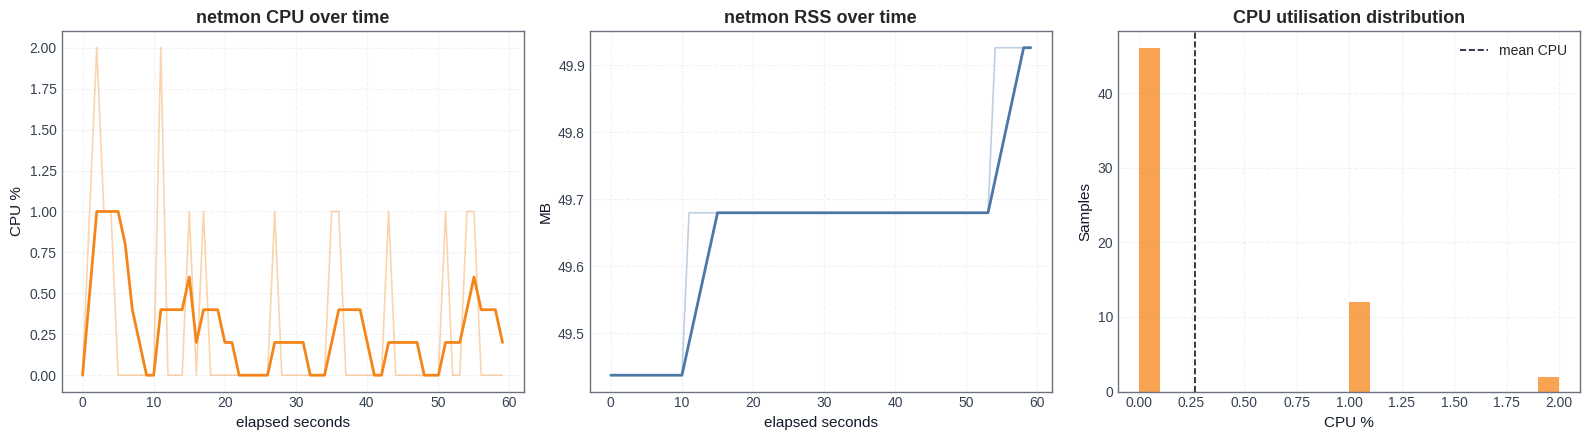

[+] Saved live-overhead plot: /home/merin/projects/ebpf-net-sentinel/data/reports/overheads/netmon_live_run3_plots_seed42.png


In [ ]:
live_summary = None
if LIVE_OUT_JSON.exists():
    live_data = json.loads(LIVE_OUT_JSON.read_text())
    live_summary = live_data.get('netmon_overhead')

if live_summary:
    live_df = pd.read_csv(live_summary['csv'])
    live_table = pd.DataFrame([{
        'pid': live_summary['pid'],
        'samples': live_summary['samples'],
        'cpu_percent_mean': live_summary['cpu_percent_mean'],
        'cpu_percent_p95': live_summary['cpu_percent_p95'],
        'rss_mb_mean': live_summary['rss_mb_mean'],
        'rss_mb_p95': live_summary['rss_mb_p95'],
        'duration_s': live_summary.get('duration_s', LIVE_SAMPLE_DURATION_S),
        'interval_s': live_summary.get('interval_s', LIVE_SAMPLE_INTERVAL_S),
    }])
    live_summary_out = REPO_ROOT / 'data' / 'reports' / 'overheads' / f'{LIVE_TAG}_summary_seed{RANDOM_SEED}.csv'
    live_table.to_csv(live_summary_out, index=False)
    print(live_table.to_string(index=False, float_format='{:.4f}'.format))
    print(f'[+] Saved live-overhead summary table: {live_summary_out}')

    live_df = live_df.copy()
    live_df['elapsed_s'] = live_df['ts'] - live_df['ts'].min()
    live_df['rss_mb'] = live_df['rss_bytes'] / (1024 ** 2)
    live_df['rolling_cpu'] = live_df['cpu_percent'].rolling(window=5, min_periods=1).mean()
    live_df['rolling_rss_mb'] = live_df['rss_mb'].rolling(window=5, min_periods=1).mean()

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    axes[0].plot(live_df['elapsed_s'], live_df['cpu_percent'], color=EBPF_COLOR, alpha=0.35, linewidth=1.2)
    axes[0].plot(live_df['elapsed_s'], live_df['rolling_cpu'], color=EBPF_COLOR, linewidth=2.0)
    axes[0].set_title('netmon CPU over time')
    axes[0].set_ylabel('CPU %')
    axes[0].set_xlabel('elapsed seconds')

    axes[1].plot(live_df['elapsed_s'], live_df['rss_mb'], color=BASELINE_COLOR, alpha=0.35, linewidth=1.2)
    axes[1].plot(live_df['elapsed_s'], live_df['rolling_rss_mb'], color=BASELINE_COLOR, linewidth=2.0)
    axes[1].set_title('netmon RSS over time')
    axes[1].set_ylabel('MB')
    axes[1].set_xlabel('elapsed seconds')

    axes[2].hist(live_df['cpu_percent'], bins=min(20, max(5, len(live_df) // 3)), color=EBPF_COLOR, alpha=0.75)
    axes[2].axvline(live_summary['cpu_percent_mean'], color='#111827', linestyle='--', linewidth=1.2, label='mean CPU')
    axes[2].set_title('CPU utilisation distribution')
    axes[2].set_xlabel('CPU %')
    axes[2].set_ylabel('Samples')
    axes[2].legend()

    plt.tight_layout()
    live_plot_out = REPO_ROOT / 'data' / 'reports' / 'overheads' / f'{LIVE_TAG}_plots_seed{RANDOM_SEED}.png'
    plt.savefig(live_plot_out, dpi=150)
    plt.show()
    print(f'[+] Saved live-overhead plot: {live_plot_out}')
else:
    print(f'[!] Live-overhead JSON not found or contains no netmon sample: {LIVE_OUT_JSON}')


In [ ]:
# Overhead robustness: aggregate all saved netmon live run files
# Looks for netmon_live_run*.json files in data/reports/overheads/ and computes
# mean +/- std across runs.

import json
import pandas as pd

run_files = sorted(OVERHEADS_DIR.glob('netmon_live_run*_seed*.json'))
print(f'[*] Found {len(run_files)} live netmon run file(s):')
for p in run_files:
    print(f'    {p.name}')

run_rows = []
for p in run_files:
    try:
        d = json.loads(p.read_text())
        s = d.get('netmon_overhead', d)
        run_rows.append({
            'file': p.name,
            'cpu_mean': float(s.get('cpu_percent_mean', s.get('cpu_mean', float('nan')))),
            'cpu_p95':  float(s.get('cpu_percent_p95', s.get('cpu_p95', float('nan')))),
            'rss_mb_mean': float(s.get('rss_mb_mean', s.get('rss_mean', float('nan')))),
            'rss_mb_p95':  float(s.get('rss_mb_p95', s.get('rss_p95', float('nan')))),
            'samples': int(s.get('samples', 0)),
            'duration_s': float(s.get('duration_s', float('nan'))),
            'platform': str(s.get('platform', 'unknown')),
        })
    except Exception as e:
        print(f'[!] Could not parse {p.name}: {e}')

if run_rows:
    runs_df = pd.DataFrame(run_rows)
    print('[*] Per-run summary:')
    print(runs_df.to_string(index=False, float_format='{:.3f}'.format))

    n_runs = len(runs_df)
    cpu_vals = runs_df['cpu_mean'].dropna().values
    rss_vals = runs_df['rss_mb_mean'].dropna().values

    print(f'[*] Aggregated overhead ({n_runs} run(s)):')
    if n_runs >= 2:
        print(f'    CPU%  : mean = {cpu_vals.mean():.3f}  std = {cpu_vals.std(ddof=1):.3f}  '
              f'range = [{cpu_vals.min():.3f}, {cpu_vals.max():.3f}]')
        print(f'    RSS MB: mean = {rss_vals.mean():.3f}  std = {rss_vals.std(ddof=1):.3f}  '
              f'range = [{rss_vals.min():.3f}, {rss_vals.max():.3f}]')
        agg_summary = {
            'n_runs': n_runs,
            'cpu_percent_mean': float(cpu_vals.mean()),
            'cpu_percent_std': float(cpu_vals.std(ddof=1)),
            'rss_mb_mean': float(rss_vals.mean()),
            'rss_mb_std': float(rss_vals.std(ddof=1)),
        }
    else:
        print(f'    CPU%  : {cpu_vals[0]:.3f}%  (N=1, indicative only)')
        print(f'    RSS MB: {rss_vals[0]:.3f} MB  (N=1, indicative only)')
        agg_summary = {
            'n_runs': 1,
            'cpu_percent_mean': float(cpu_vals[0]),
            'cpu_percent_std': float('nan'),
            'rss_mb_mean': float(rss_vals[0]),
            'rss_mb_std': float('nan'),
        }

    agg_path = REPORTS_DIR / 'overheads' / f'netmon_live_aggregated_seed{RANDOM_SEED}.json'
    agg_path.write_text(json.dumps(agg_summary, indent=2))
    print(f'[+] Saved aggregated overhead summary: {agg_path}')
else:
    print('[!] No live netmon run files found. Run the live sampling cells (above) first.')
    n_runs = 0
    agg_summary = None


[*] Found 3 live netmon run file(s):
    netmon_live_run1_seed42.json
    netmon_live_run2_seed42.json
    netmon_live_run3_seed42.json

[*] Per-run summary:
                        file  cpu_mean  cpu_p95  rss_mb_mean  rss_mb_p95  samples  duration_s                                       platform
netmon_live_run1_seed42.json     0.283    2.000       50.409      50.496       60      60.000 Linux-5.15.0-139-generic-x86_64-with-glibc2.29
netmon_live_run2_seed42.json     0.517    2.000       60.328      60.328       60      60.000 Linux-5.15.0-139-generic-x86_64-with-glibc2.29
netmon_live_run3_seed42.json     0.267    1.000       49.660      49.926       60      60.000 Linux-5.15.0-139-generic-x86_64-with-glibc2.29

[*] Aggregated overhead (3 run(s)):
    CPU%  : mean = 0.356  std = 0.140  range = [0.267, 0.517]
    RSS MB: mean = 53.466  std = 5.955  range = [49.660, 60.328]
[+] Saved aggregated overhead summary: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/overhead

## Summary

**RQ4:** Adding eBPF features has negligible effect on ML inference cost.

Inference latency (10k rows, 7 repeats):
- Baseline: 5.59 ms per 1k rows, 1.11 MB model
- eBPF: 5.18 ms per 1k rows, 1.12 MB model (marginally faster, within measurement noise)

Live eBPF collector (3 runs, bare-metal Ubuntu 20.04):
- CPU: mean 0.36% +/- 0.14%, p95 1.0-2.0%
- RSS: mean 53.5 MB +/- 5.96 MB

Idle overhead is low. Both CPU and memory will rise under active attack traffic, so these figures are a lower bound for production use.